In [9]:
import pandas as pd
import yfinance as yf
import quantstats as qs
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../src'))

# Import all our pipeline functions
from data_loader import download_price_data, clean_price_data
from factors import compute_momentum, compute_volatility, compute_cross_sectional_zscore
from signals import build_composite_signal
from backtest import generate_target_weights, calculate_portfolio_returns, calculate_portfolio_performance

# Tell quantstats to use matplotlib for rendering in Jupyter
qs.extend_pandas()

In [3]:
# 1. Define Universe & Dates
mvp_universe = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
    'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
    'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM'
]
start_date = '2021-01-01'
end_date = '2026-12-31'

# 2. Data Loader
prices_raw, _ = download_price_data(mvp_universe, start_date, end_date)
prices = clean_price_data(prices_raw)
daily_returns = prices.pct_change(fill_method=None).dropna()

# 3. Factor Engine
raw_momentum = compute_momentum(prices).dropna(how='all')
raw_volatility = compute_volatility(daily_returns).dropna(how='all')

z_momentum = compute_cross_sectional_zscore(raw_momentum)
z_low_vol = -compute_cross_sectional_zscore(raw_volatility) # Inverted for low vol

# 4. Signal & Backtest Engine
composite_scores = build_composite_signal(z_momentum, z_low_vol, weight_mom=0.6, weight_vol=0.4)
target_weights = generate_target_weights(composite_scores, top_n=10)

# 5. Calculate Actual Returns
strategy_returns = calculate_portfolio_returns(target_weights, daily_returns)
strategy_returns.name = "Multi-Factor MVP"

2026-03-27 12:43:01,268 - INFO - Downloading data for 30 tickers from 2021-01-01 to 2026-12-31...
2026-03-27 12:43:03,032 - INFO - Shape before cleaning: (1313, 30)
2026-03-27 12:43:03,037 - INFO - Shape after cleaning: (1313, 30) (0 dropped)
2026-03-27 12:43:03,041 - INFO - Computing momentum (lookback=252, skip=21)...
2026-03-27 12:43:03,044 - INFO - Computing annualized rolling volatility (window=252)...
2026-03-27 12:43:03,049 - INFO - Computing cross-sectional z-scores...
2026-03-27 12:43:03,053 - INFO - Computing cross-sectional z-scores...
2026-03-27 12:43:03,056 - INFO - Building composite signal (Momentum: 60%, Low-Vol: 40%)...
2026-03-27 12:43:03,057 - INFO - Generating monthly target weights for top 10 stocks...
/Users/lorenzocc/Desktop/8. Programming/ServiceFabric/portport/src/backtest.py:16: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly_scores = composite_scores.resample('BM').last()
2026-03-27 12:43:03,084 -

In [4]:
# Download SPY (S&P 500 ETF) to compare our performance against the broader market
benchmark_data = yf.download('SPY', start=strategy_returns.index[0], end=end_date, auto_adjust=True, progress=False)
benchmark_returns = benchmark_data['Close'].pct_change().dropna()
# If yfinance returns a DataFrame with a single column, grab the Series
if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.iloc[:, 0]
    
benchmark_returns.name = "S&P 500 (SPY)"

# Align the dates perfectly
strategy_returns, benchmark_returns = strategy_returns.align(benchmark_returns, join='inner')


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2022-02-01   2022-02-01
End Period           2026-03-26   2026-03-26
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       100.0%

Cumulative Return    51.99%       73.75%
CAGR﹪               10.67%       14.31%

Sharpe               0.66         0.9
Prob. Sharpe Ratio   91.12%       96.57%
Sortino              0.95         1.3
Sortino/√2           0.67         0.92
Omega                1.13         1.17

Max Drawdown         -22.09%      -22.9%
Max DD Date          2022-10-12   2025-04-08
Max DD Period Start  2022-03-30   2025-02-18
Max DD Period End    2023-07-17   2026-03-26
Longest DD Days      475          442

Gain/Pain Ratio      0.13         0.17
Gain/Pain (1M)       0.68         1.01

Payoff Rati

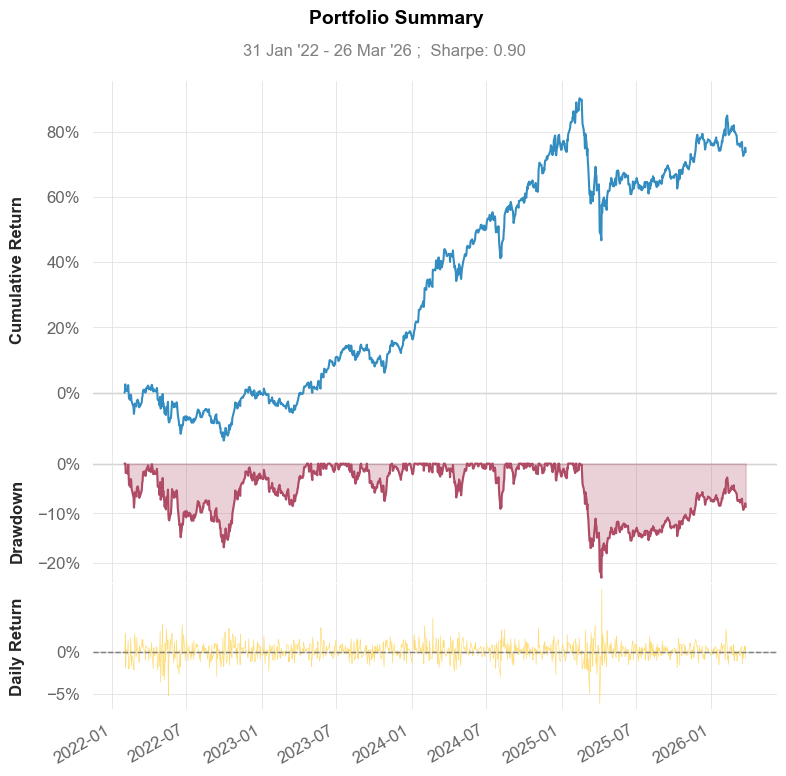

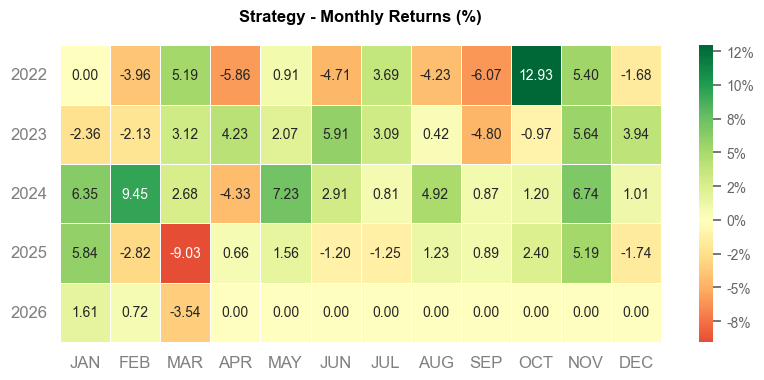

In [5]:
# QuantStats handles all the complex math for Sharpe, Sortino, Drawdowns, etc.
# This will generate a beautiful HTML-like output directly in your notebook.

qs.reports.basic(strategy_returns, benchmark=benchmark_returns)

<Figure size 1200x600 with 0 Axes>

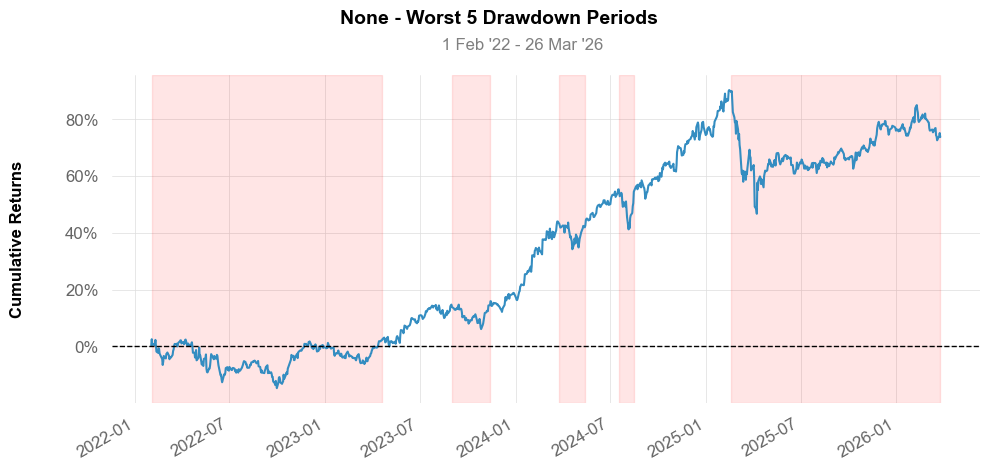

<Figure size 1200x600 with 0 Axes>

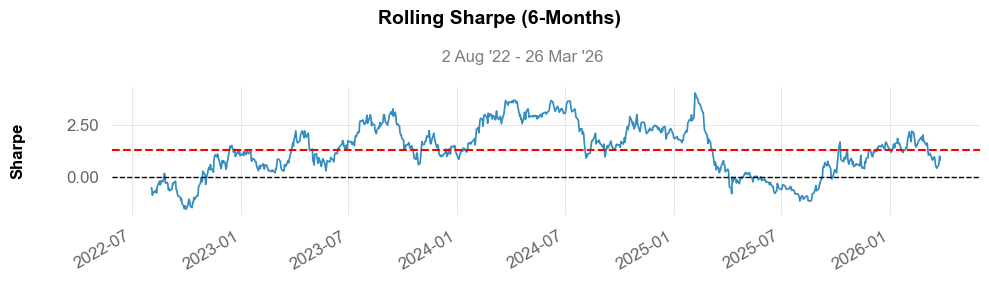

In [6]:
# If you want to see specific charts outside the tearsheet, QuantStats has them built-in.
# For example, the Drawdown profile:

fig = plt.figure(figsize=(12, 6))
qs.plots.drawdowns_periods(strategy_returns, prepare_returns=False)
plt.show()

# Or the rolling Sharpe ratio:
fig = plt.figure(figsize=(12, 6))
qs.plots.rolling_sharpe(strategy_returns)
plt.show()

<Axes: title={'center': 'The Impact of Transaction Costs'}, xlabel='Date'>

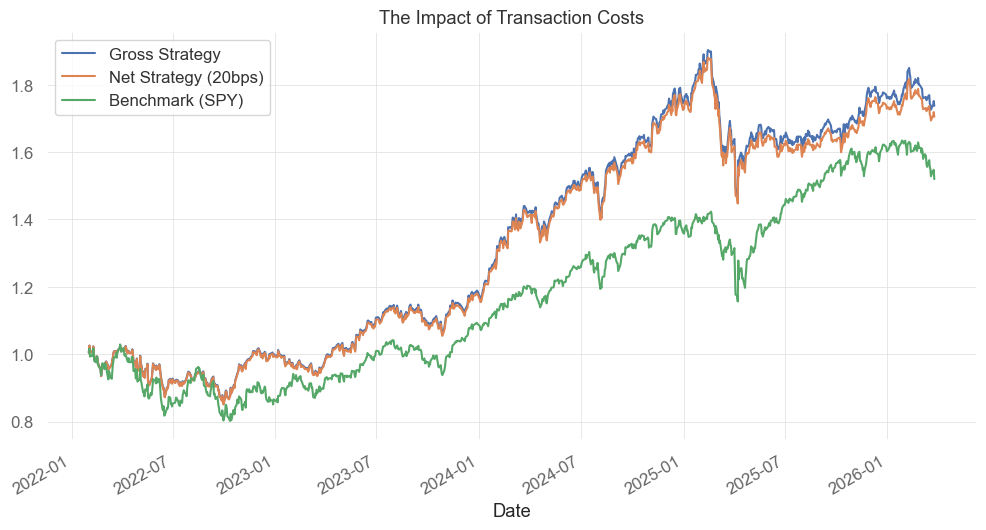

In [7]:
from backtest import calculate_portfolio_returns_net

# Calculate Net Returns assuming 20bps cost per trade
net_returns, monthly_turnover = calculate_portfolio_returns_net(target_weights, daily_returns, cost_bps=20)
net_returns.name = "Multi-Factor (Net)"

# Compare them!
comparison_df = pd.DataFrame({
    'Gross Strategy': strategy_returns,
    'Net Strategy (20bps)': net_returns,
    'Benchmark (SPY)': benchmark_returns
}).dropna()

# Plot Cumulative Performance
(1 + comparison_df).cumprod().plot(figsize=(12, 6), title="The Impact of Transaction Costs")

2026-03-27 12:43:52,945 - INFO - Calculating performance with 20 bps transaction cost...


--- STRATEGY PERFORMANCE (NET OF COSTS) ---

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2022-02-02   2022-02-02
End Period           2026-03-26   2026-03-26
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       100.0%

Cumulative Return    50.97%       66.71%
CAGR﹪               10.5%        13.18%

Sharpe               0.65         0.84
Prob. Sharpe Ratio   90.81%       95.52%
Sortino              0.94         1.21
Sortino/√2           0.66         0.86
Omega                1.12         1.16

Max Drawdown         -22.09%      -23.14%
Max DD Date          2022-10-12   2025-04-08
Max DD Period Start  2022-03-30   2025-02-18
Max DD Period End    2023-07-17   2026-03-26
Longest DD Days      475          470

Gain/Pain Ratio      0.12         0.16
Gain

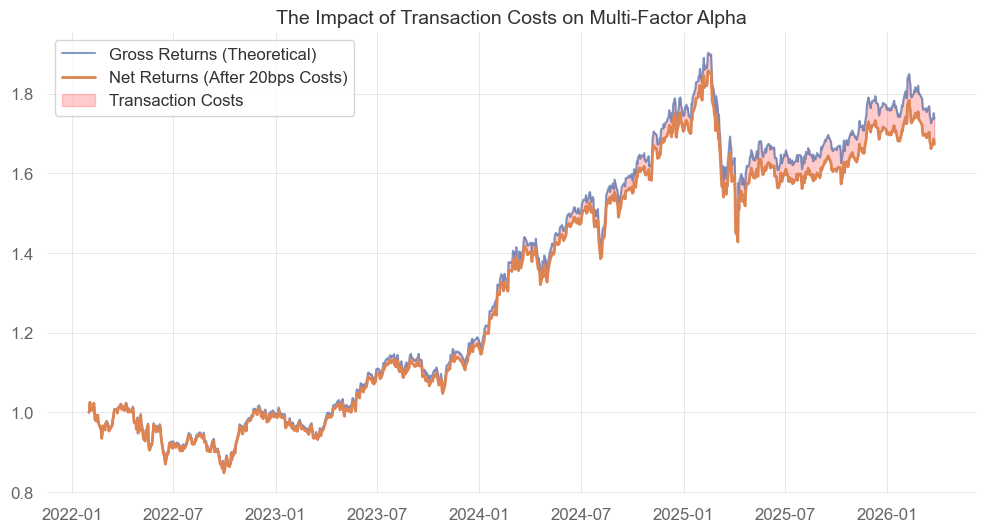

In [10]:
# 1. Calculate Gross and Net returns (Assuming 20 bps for a retail/mid-institutional mix)
gross_ret, net_ret = calculate_portfolio_performance(target_weights, daily_returns, cost_bps=20)

# 2. Compare using QuantStats
print("--- STRATEGY PERFORMANCE (NET OF COSTS) ---")
qs.reports.metrics(net_ret, benchmark=benchmark_returns)

# 3. Visualize the "Cost Gap"
# This shows how much money was lost to the broker/slippage over time
cumulative_gross = (1 + gross_ret).cumprod()
cumulative_net = (1 + net_ret).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cumulative_gross, label='Gross Returns (Theoretical)', alpha=0.7)
ax.plot(cumulative_net, label='Net Returns (After 20bps Costs)', linewidth=2)
ax.fill_between(cumulative_gross.index, cumulative_net, cumulative_gross, color='red', alpha=0.2, label='Transaction Costs')

ax.set_title("The Impact of Transaction Costs on Multi-Factor Alpha", fontsize=14)
ax.legend()
plt.show()